<a href="https://colab.research.google.com/github/sharvmahajan/TE/blob/DSBDAL/A10/DSBDAL_Assignment_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DSBDAL Assignment 10

Name : Sharv Mahajan

Roll No. : 31430

### Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score

### Load Dataset

In [2]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Basic dataset information

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### Data Visualization

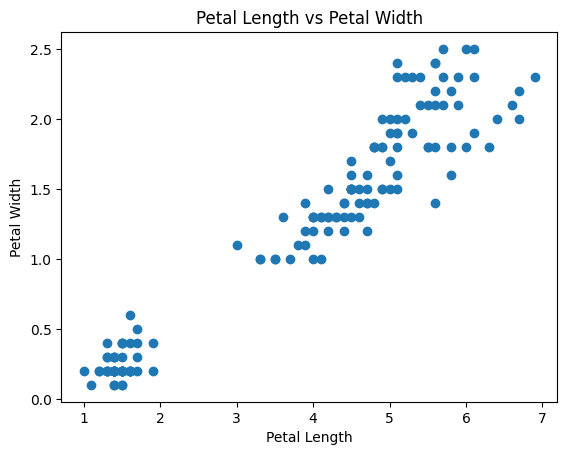

In [4]:
plt.figure()
plt.scatter(df['petal length (cm)'], df['petal width (cm)'])
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Petal Length vs Petal Width")
plt.show()

### Train Test Split
(70% training, 30% testing)

In [5]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 105
Testing samples: 45


### Apply Gaussian Naïve Bayes

In [6]:
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

### Confusion Matrix

In [7]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n")
print(cm)

Confusion Matrix:

[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]


### Calculate TP, FP, TN, FN

In [8]:
TP = cm[0][0]
FN = cm[0][1] + cm[0][2]
FP = cm[1][0] + cm[2][0]
TN = cm[1][1] + cm[1][2] + cm[2][1] + cm[2][2]

print("TP:", TP)
print("FP:", FP)
print("TN:", TN)
print("FN:", FN)

TP: 19
FP: 0
TN: 26
FN: 0


### Accuracy, Error Rate, Precision, Recall

In [9]:
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.9777777777777777
Error Rate: 0.022222222222222254
Precision: 0.9761904761904763
Recall: 0.9743589743589745


$P(C \mid X) = \frac{P(X \mid C)\, P(C)}{P(X)}$

### Where:

- $P(C \mid X)$ = Posterior Probability  
- $P(X \mid C)$ = Likelihood  
- $P(C)$ = Prior Probability  
- $P(X)$ = Evidence

### Overall Conclusion

The Gaussian Naïve Bayes classifier performs extremely well on the Iris dataset.

Very high accuracy, precision, and recall indicate:

- Good class separation

- Minimal misclassification

Iris dataset is well-structured and linearly separable, which helps Naïve Bayes perform strongly.